In [2]:
import pandas as pd

# Replace 'filename.csv' with the path to your CSV file
df = pd.read_csv('project.csv')

# Display the first 5 rows
print(df.head())


/var/folders/x5/rmz6246d09j8njb7w95f59lc0000gn/T/ipykernel_8990/3497244856.py:4: DtypeWarning: Columns (2,4,5,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('project.csv')


  metroplex state zip_code                                    hospital  \
0    Austin    TX    78717  Dell Childrens Medical Center North Campus   
1    Austin    TX    78717  Dell Childrens Medical Center North Campus   
2    Austin    TX    78717  Dell Childrens Medical Center North Campus   
3    Austin    TX    78717  Dell Childrens Medical Center North Campus   
4    Austin    TX    78717  Dell Childrens Medical Center North Campus   

  billing_code gross_charge  insurer_price  max_price  discounted_cash  \
0        99281       289.25            0.0     276.39           109.92   
1        99281       289.25            0.0     276.39           109.92   
2        99281       289.25            0.0     276.39           109.92   
3        99282        329.5            0.0     209.85           125.21   
4        99282        329.5            0.0     209.85           125.21   

       description  payer_name                      plan_name  \
0   VISIT ER LVL I     champva  1135_CHAMPVA 

#### how close cash prices are to insurer-negotiated prices for each insurance plan — essentially checking how much more (or less) patients might pay if they pay directly in cash versus using insurance.

In [32]:
# Calculate absolute difference between cash and insurer prices
df['cash_vs_insurer_diff'] = abs(df['discounted_cash'] - df['insurer_price'])

# Group by plan name, drop NaNs, then sort and take top 10
fair_plans = (df.groupby('plan_name')['cash_vs_insurer_diff'].mean().dropna().sort_values())

# Display result
print("Plans where cash prices are closest to insurer prices:")
print(fair_plans.head(10))


Plans where cash prices are closest to insurer prices:
plan_name
MULTIPLAN                                                                                                           0.000000
 MEDICARE ADVANTAGE|ADVANTAGE PLUS|DUALS                                                                            0.193522
 ADVANTAGE                                                                                                          0.193522
 ADVANTAGE|ADVANTAGE PLUS                                                                                           0.193522
 MEDICARE|FIDA DUAL ADVANTAGE                                                                                       0.193522
 MEDICARE ADVANTAGE|MAP                                                                                             0.193522
 MEDICARE ADVANTAGE|DUAL SPECIAL NEED|INSTITUTIONAL SPECIAL NEEDS|MEDICAID ADVANTAGE PLUS|MANAGED LONG TERM CARE    0.193522
 MEDICARE ADVANTAGE                                         

/var/folders/x5/rmz6246d09j8njb7w95f59lc0000gn/T/ipykernel_8990/3552136406.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


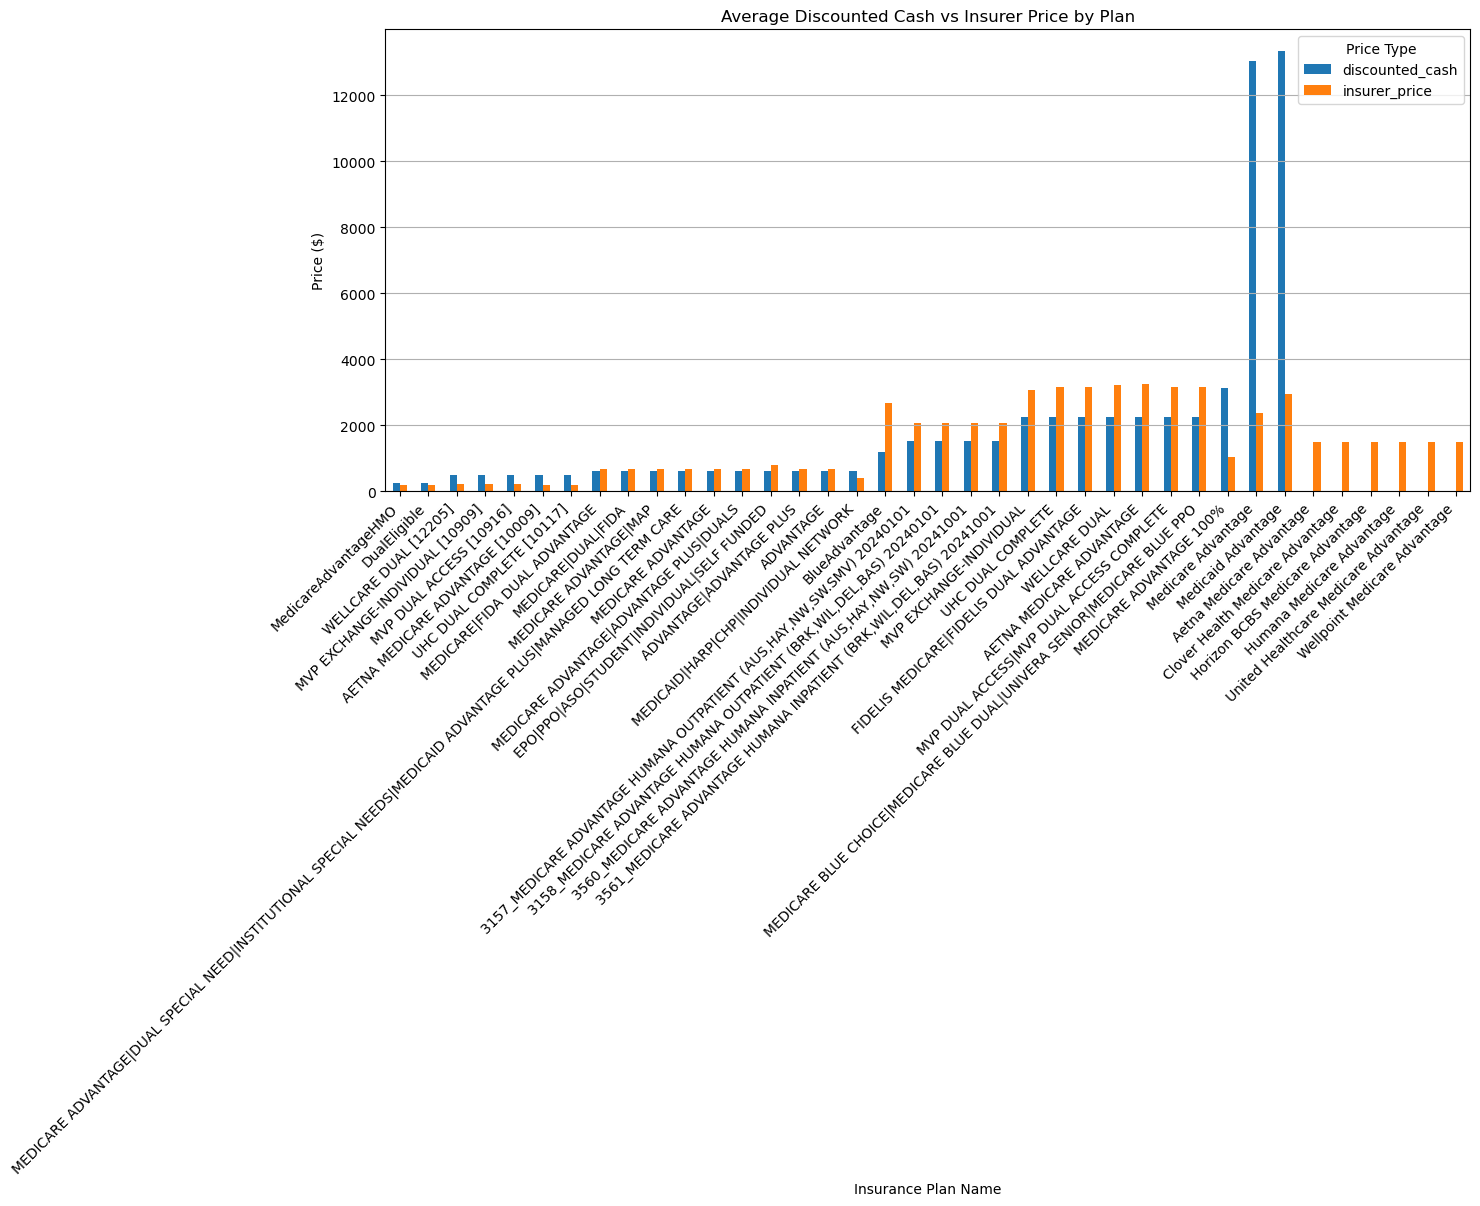

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# Clean up plan names
df['plan_name'] = df['plan_name'].str.strip()

# Target keywords to search for (simplified, more robust matching)
keywords = [
    'MEDICARE ADVANTAGE',
    'ADVANTAGE',
    'DUAL',
    'FIDA',
    'MAP'
]

# Filter plans that contain any of the keywords
mask = df['plan_name'].str.upper().apply(lambda x: any(kw in x for kw in keywords))
filtered_df = df[mask]

# Check if anything was matched
if filtered_df.empty:
    print("No matching plans found. Please check the plan_name formatting.")
else:
    # Group and calculate average prices
    plan_prices = filtered_df.groupby('plan_name')[['discounted_cash', 'insurer_price']].mean()

    # Sort for clarity
    plan_prices = plan_prices.sort_values(by='discounted_cash')

    # Plot
    plan_prices.plot(kind='bar', figsize=(14, 6))
    plt.title('Average Discounted Cash vs Insurer Price by Plan')
    plt.ylabel('Price ($)')
    plt.xlabel('Insurance Plan Name')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Price Type')
    plt.tight_layout()
    plt.grid(axis='y')
    plt.show()


In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Step 1: Aggregate price data per hospital
price_features = df.groupby('hospital')[['discounted_cash', 'insurer_price', 'max_price']].mean()

# Step 2: Drop hospitals with missing values
price_features = price_features.dropna()

# Step 3: Scale features
scaler = StandardScaler()
scaled = scaler.fit_transform(price_features)

# Step 4: K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
price_features['cluster'] = kmeans.fit_predict(scaled)

# Step 5: Review clustered hospitals
print(price_features.sort_values('cluster'))


                                                  discounted_cash  \
hospital                                                            
Ascension Seton Medical Center Austin                  364.158284   
Ascension Seton Northwest Hospital                     380.051611   
Ascension Seton Shoal Creek                            178.600000   
Ascension Seton Williamson Hospital                    281.846840   
Dell Childrens Medical Center North Campus             345.561755   
Newark-Wayne Community Hospital                       2224.332152   
Saint Josephs Medical Center                           633.976936   
Saint Michaels Medical Center                         1769.067128   
St. Davids North Austin Medical Center                3723.753460   
University Hospital                                   1426.557342   
Wayne Memorial Hospital                               3125.264089   
Baylor Scott & White Medical Center – Round Rock         0.000000   
New York Presbyterian System      

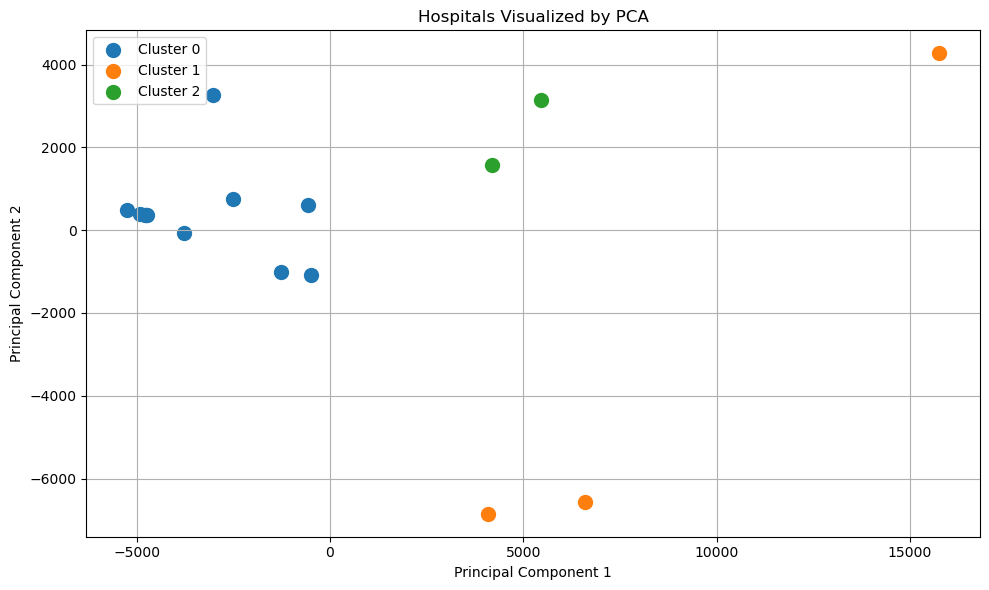

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Select features and drop rows with NaN (important for PCA)
features = price_features[['discounted_cash', 'insurer_price', 'max_price']].dropna()
clusters = price_features.loc[features.index, 'cluster']

# PCA to reduce to 2D
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['hospital'] = features.index
pca_df['cluster'] = clusters.values

# Plotting
plt.figure(figsize=(10, 6))
for cluster_id in sorted(pca_df['cluster'].unique()):
    cluster_data = pca_df[pca_df['cluster'] == cluster_id]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'], label=f'Cluster {cluster_id}', s=100)

plt.title('Hospitals Visualized by PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Interpretation of the Clusters:
#### Cluster 0 – “Affordable/Moderate-Price Hospitals”
Discounted Cash: ~$100–$3,700

Insurer Price: Mostly < $2,000

Max Prices: Generally < $4,000

Likely to reflect hospitals that:

Serve mid-income populations.

Have more transparent and moderate pricing.

Possibly non-profit or part of larger systems (Ascension, Dell Children’s, etc.).
#### Cluster 1 – “Premium/High List Price Hospitals”
Includes:

New York Presbyterian System

Baylor Scott & White Medical Center – Round Rock

St. David’s Round Rock

Discounted Cash: Up to ~$15K

Max Prices: Up to ~$14K

Possibly academic, prestigious, or specialty hospitals.

Higher insurer prices suggest more complex care or brand pricing power.
#### Cluster 2 – “Price Outliers or Strategy-Driven”
Heart Hospital of Austin & NYP Queens:

Odd mix: high cash prices (Heart Hospital at ~$6,500), but low insurer prices.

Suggests:

Strategic cash pricing to capture out-of-network patients.

Negotiated low insurer prices (possibly due to payer leverage).

## Hospital Price Transparency Discrepancy Insights

In [61]:

# Clean and convert to numeric
df['insurer_price'] = pd.to_numeric(df['insurer_price'], errors='coerce')
df['discounted_cash'] = pd.to_numeric(df['discounted_cash'], errors='coerce')

# Drop rows with missing prices
df = df.dropna(subset=['insurer_price', 'discounted_cash'])

# Create a discrepancy column
df['discrepancy'] = df['insurer_price'] - df['discounted_cash']

/var/folders/x5/rmz6246d09j8njb7w95f59lc0000gn/T/ipykernel_8990/2890492258.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['discrepancy'] = df['insurer_price'] - df['discounted_cash']


/var/folders/x5/rmz6246d09j8njb7w95f59lc0000gn/T/ipykernel_8990/3389486865.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='discrepancy_flag', palette='Set2')


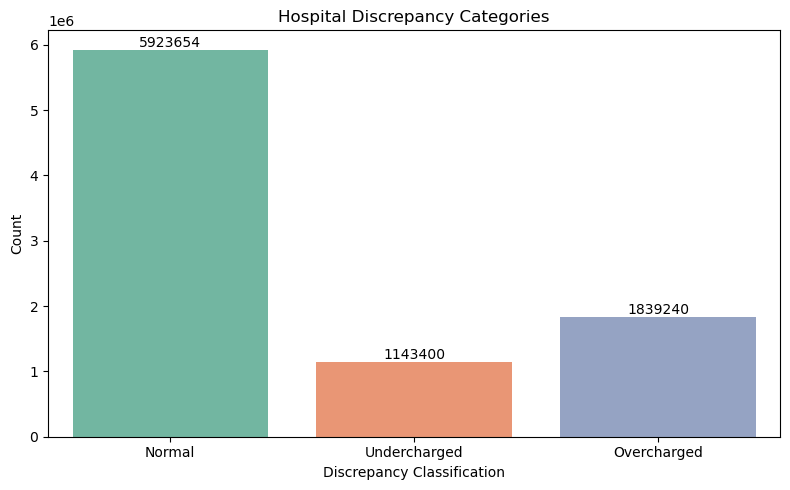

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the classification column
df['discrepancy_flag'] = df['discrepancy'].apply(
    lambda x: 'Overcharged' if x > 500 else ('Undercharged' if x < -500 else 'Normal')
)

# Create the count plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='discrepancy_flag', palette='Set2')

# Add count labels on top of bars
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(str(count), (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)

# Add titles and labels
plt.title("Hospital Discrepancy Categories")
plt.xlabel("Discrepancy Classification")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [73]:
# Count the number of entries in each discrepancy category
discrepancy_counts = df['discrepancy_flag'].value_counts()
print(discrepancy_counts)


discrepancy_flag
Normal          5923654
Overcharged     1839240
Undercharged    1143400
Name: count, dtype: int64


/var/folders/x5/rmz6246d09j8njb7w95f59lc0000gn/T/ipykernel_8990/1596063345.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(data=df_plot, x='discrepancy_flag', y='count', palette=palette)


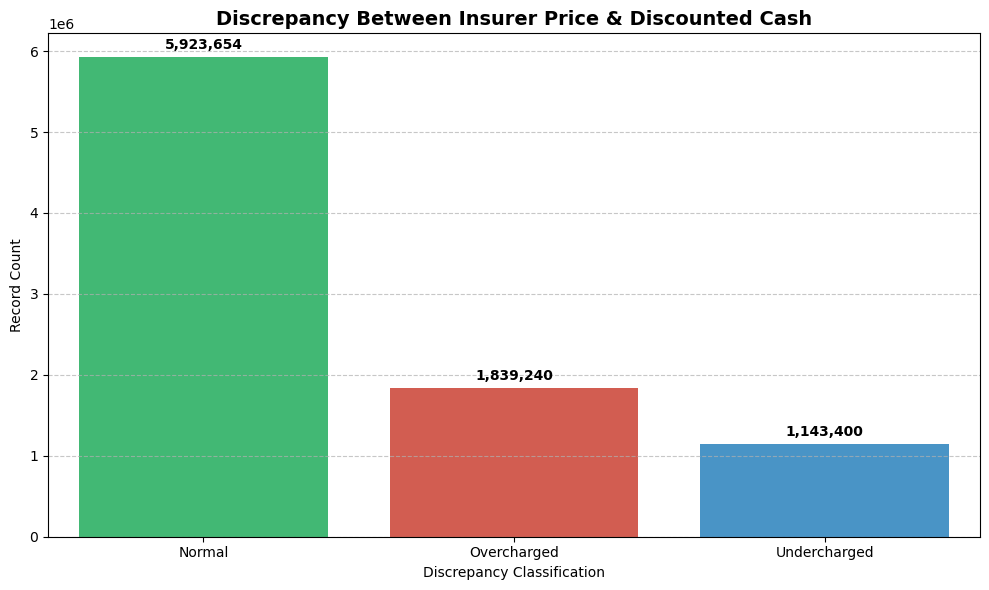

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Simulated counts
discrepancy_counts = pd.Series({
    'Normal': 5923654,
    'Overcharged': 1839240,
    'Undercharged': 1143400
})

# Prepare DataFrame for plotting
df_plot = discrepancy_counts.reset_index()
df_plot.columns = ['discrepancy_flag', 'count']

# Set colors for each category
palette = {
    'Overcharged': '#e74c3c',  # red
    'Undercharged': '#3498db',  # blue
    'Normal': '#2ecc71'  # green
}

# Create the plot
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(data=df_plot, x='discrepancy_flag', y='count', palette=palette)

# Add value labels on top of each bar
for index, row in df_plot.iterrows():
    bar_plot.text(index, row['count'] + 100000, f"{row['count']:,}", 
                  color='black', ha="center", fontweight='bold')

# Title and axis labels
plt.title("Discrepancy Between Insurer Price & Discounted Cash", fontsize=14, fontweight='bold')
plt.xlabel("Discrepancy Classification")
plt.ylabel("Record Count")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [81]:
discrepancy_counts = df['discrepancy_flag'].value_counts()
discrepancy_counts

discrepancy_flag
Normal          5923654
Overcharged     1839240
Undercharged    1143400
Name: count, dtype: int64

## hospital-based and insurer-based pricing discrepancies

Top 5 Hospitals with Highest Average Discrepancy:
hospital
Baylor Scott & White Medical Center – Round Rock    5334.845343
St. Davids Round Rock Medical Center                2198.574949
Newark-Wayne Community Hospital                      710.581168
University Hospital                                  617.380007
Saint Josephs Medical Center                          23.768721
Name: discrepancy, dtype: float64


/var/folders/x5/rmz6246d09j8njb7w95f59lc0000gn/T/ipykernel_8990/1703881323.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hospital_discrepancy.head(5).index, y=hospital_discrepancy.head(5).values, palette='viridis')


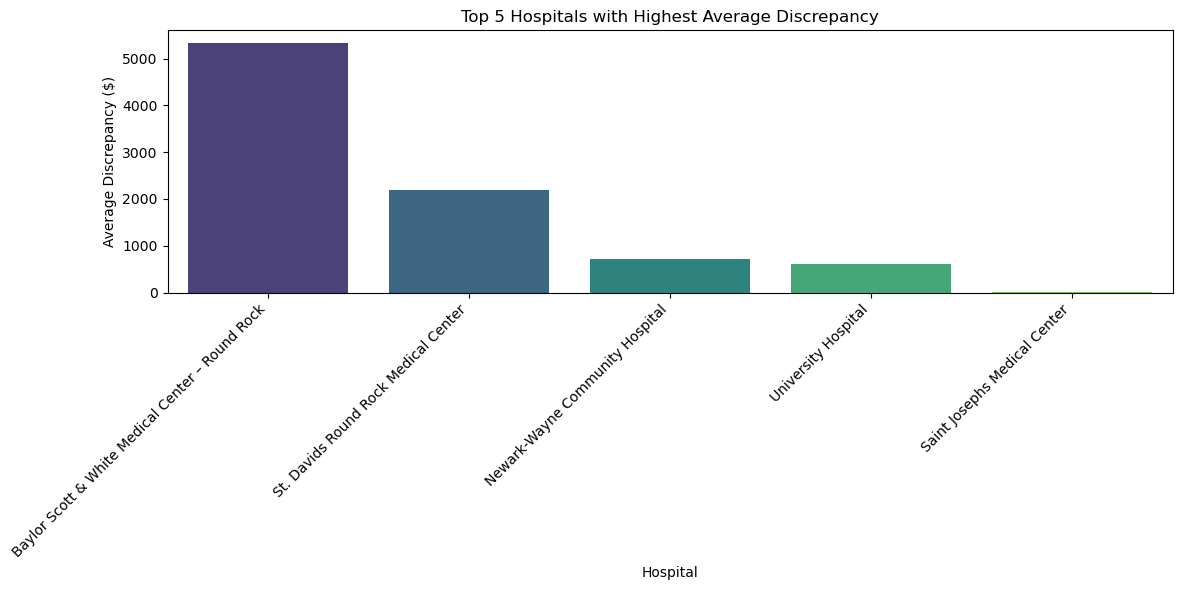


Top 10 Insurers with Highest Average Discrepancy:
payer_name
evry health               10153.130122
healthcare highways        5356.549017
blue cross blue shield     5199.163143
american health plan       4058.004786
moda ppo                   3192.121651
united                     3179.724744
humana                     2900.183587
bcbs                       2891.676885
humana ppo                 2862.305055
moda                       2790.123699
Name: discrepancy, dtype: float64


/var/folders/x5/rmz6246d09j8njb7w95f59lc0000gn/T/ipykernel_8990/1703881323.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=insurer_discrepancy.head(10).index, y=insurer_discrepancy.head(10).values, palette='Blues_d')


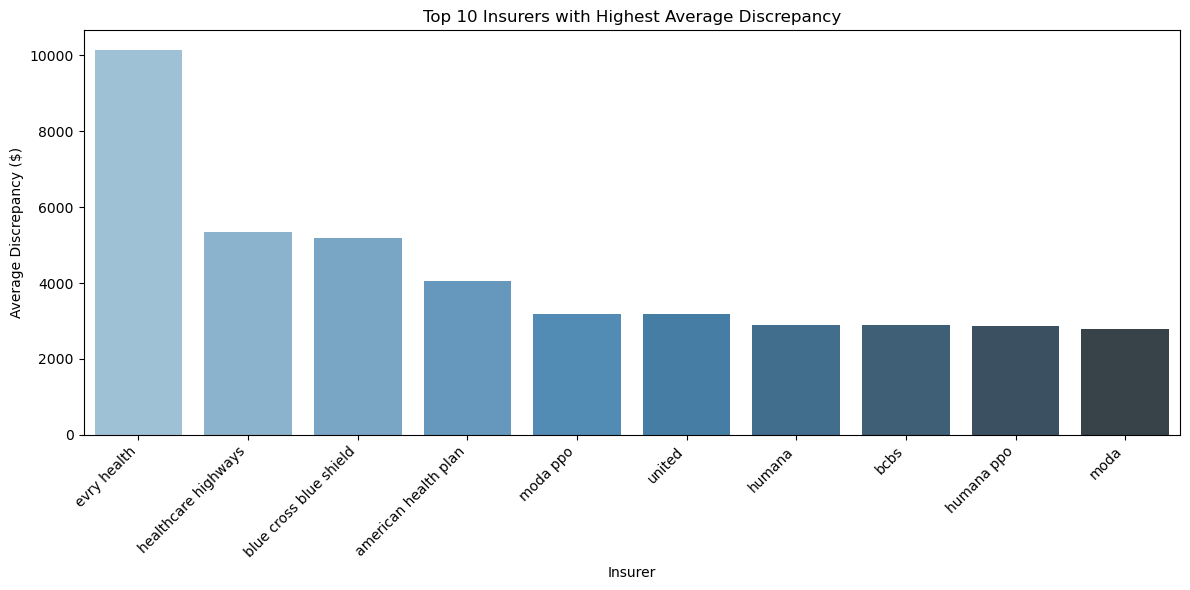

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Hospital-Based Analysis
# Calculate the mean discrepancy for each hospital
hospital_discrepancy = df.groupby('hospital')['discrepancy'].mean().sort_values(ascending=False)

# Output the numerical data for top 5 hospitals
print("Top 5 Hospitals with Highest Average Discrepancy:")
print(hospital_discrepancy.head(5))

# Plot the top 5 hospitals with highest discrepancies
plt.figure(figsize=(12, 6))
sns.barplot(x=hospital_discrepancy.head(5).index, y=hospital_discrepancy.head(5).values, palette='viridis')
plt.title('Top 5 Hospitals with Highest Average Discrepancy')
plt.xlabel('Hospital')
plt.ylabel('Average Discrepancy ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Insurer-Based Analysis (keeping the previous code for insurer-based analysis)
# Calculate the mean discrepancy for each insurer
insurer_discrepancy = df.groupby('payer_name')['discrepancy'].mean().sort_values(ascending=False)

# Output the numerical data for top 10 insurers
print("\nTop 10 Insurers with Highest Average Discrepancy:")
print(insurer_discrepancy.head(10))

# Plot the top 10 insurers with highest discrepancies
plt.figure(figsize=(12, 6))
sns.barplot(x=insurer_discrepancy.head(10).index, y=insurer_discrepancy.head(10).values, palette='Blues_d')
plt.title('Top 10 Insurers with Highest Average Discrepancy')
plt.xlabel('Insurer')
plt.ylabel('Average Discrepancy ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [89]:
hospital_discrepancy

hospital
Baylor Scott & White Medical Center – Round Rock     5334.845343
St. Davids Round Rock Medical Center                 2198.574949
Newark-Wayne Community Hospital                       710.581168
University Hospital                                   617.380007
Saint Josephs Medical Center                           23.768721
Ascension Seton Shoal Creek                           -78.600000
Saint Michaels Medical Center                        -101.546940
Ascension Seton Williamson Hospital                  -180.481720
Dell Childrens Medical Center North Campus           -197.845603
Ascension Seton Medical Center Austin                -232.818103
Ascension Seton Northwest Hospital                   -241.826990
Wayne Memorial Hospital                             -1234.418926
St. Davids North Austin Medical Center              -3720.053752
Heart Hospital of Austin                            -6377.264213
New York Presbyterian Queens                        -6790.701364
New York Presbyt

In [103]:
pip install plotly


Note: you may need to restart the kernel to use updated packages.


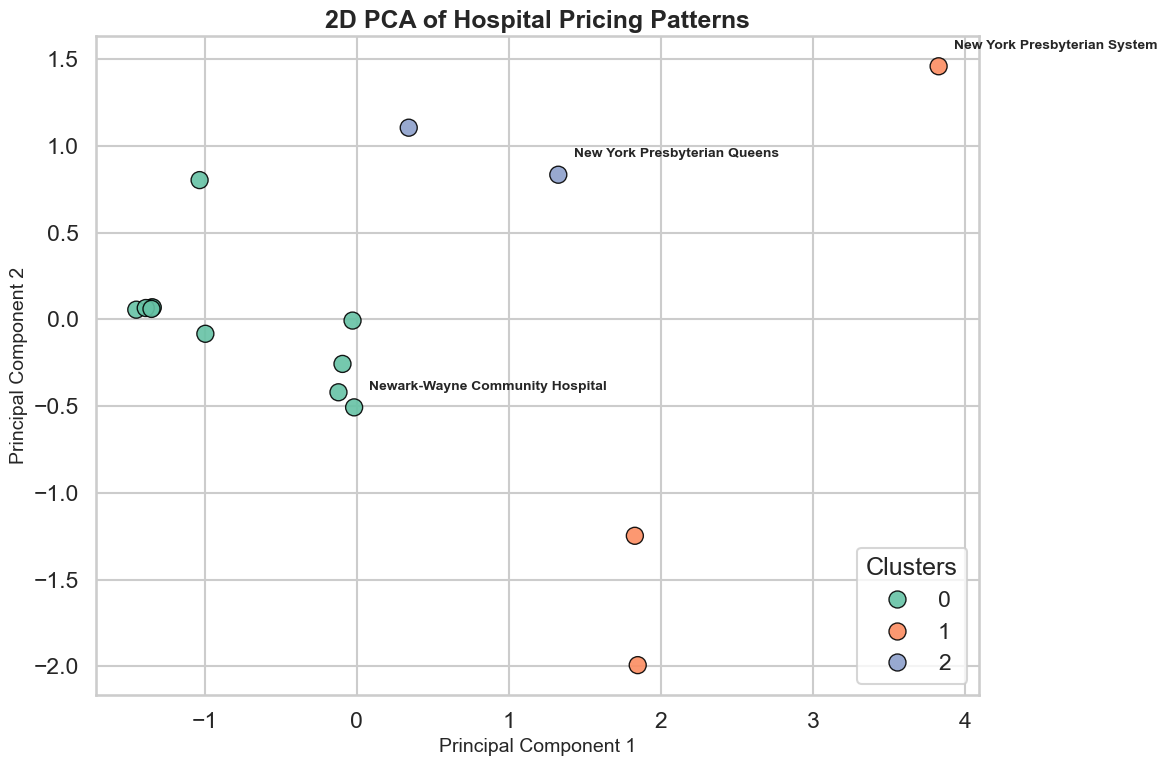

In [116]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Select and scale numeric features
numeric_features = price_features[['discounted_cash', 'insurer_price', 'max_price']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_features)

# Step 2: Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

# Step 3: Prepare DataFrame for plotting
pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
pca_df['cluster'] = price_features['cluster'].values
pca_df['hospital'] = price_features.index

# Step 4: Set up style
sns.set(style="whitegrid", context="talk")

# Step 5: Create PCA scatter plot
plt.figure(figsize=(12, 8))
palette = sns.color_palette("Set2", n_colors=3)
sns.scatterplot(
    data=pca_df,
    x='PCA1', y='PCA2',
    hue='cluster',
    palette=palette,
    s=150,
    edgecolor='black',
    alpha=0.9
)

# Step 6: Annotate top hospitals per cluster (optional but impactful)
for i in range(3):
    cluster_points = pca_df[pca_df['cluster'] == i].sort_values(by='PCA1', ascending=False).head(1)
    for _, row in cluster_points.iterrows():
        plt.text(row['PCA1']+0.1, row['PCA2']+0.1, row['hospital'], fontsize=10, weight='bold')

# Final polish
plt.title("2D PCA of Hospital Pricing Patterns", fontsize=18, weight='bold')
plt.xlabel("Principal Component 1", fontsize=14)
plt.ylabel("Principal Component 2", fontsize=14)
plt.legend(title='Clusters', loc='lower right')
plt.tight_layout()
plt.show()
